In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette("Set2")

# Leer los datos

In [3]:
df_fe = pd.read_csv("../../../data/respuestas_fede.csv")
print("Shape of data: ", df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
fig_name_prefix = 'que_es_nube'
file_ext = '.png'
dpi_value = 200
include_title = True

Shape of data:  (369, 22)


## En informática, ¿qué es la nube?

In [ ]:
# En informática, ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Una nube": "Una\nnube",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("¿Qué es la nube?\nPor escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En el mármol se elige un 10% menos la opción No se
* En el Mantovani un 5% más la opción correcta

In [ ]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\ncompus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("¿Qué es la nube?\nMisconceptions por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_agregadas_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En el Mantovani hay un 10% mas de respuestas con Misconception

In [ ]:
# Con misconception vs Sin Misconception - Desagrupando No se - ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index!='Una red de\nantenas y\nsatélites') &
                               (result.index!='No sé') &
                               (result.index!='Muchísimas\ncompus')].sum()

result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Una red de\nantenas y\nsatélites'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "Una red de\nantenas y\nsatélites",
                                2: "No sé",
                                3: "Muchísimas\ncompus"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("¿Qué es la nube?\nMisconceptions fuertes por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Ambos colegios seleccionan la misconception debil como la respuesta mas comun
* En ambos casos el Mantovani la selecciona levemente mas veces
* El modelo marmol elige no se un 10% mas que el mantovani
* El mantovani elige la respuesta correcta un 5% mas que el Modelo
* La misc debil ess elegida el doble que el resto de las misc fuertes juntas

                      Totales  Modelo Mármol  Juan Mantovani
Con\nmisconception  71.389646      65.972222       74.887892
No sé               22.888283      31.250000       17.488789
Muchísimas\ncompus   5.722071       2.777778        7.623318


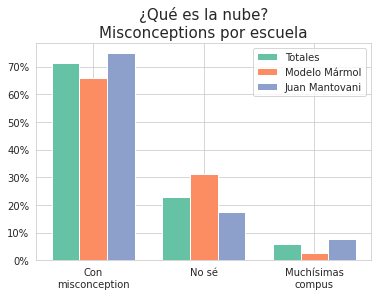

In [4]:
# Con misconception vs Sin Misconception - Desagrupando No se - ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()

result = pd.concat([ df_con_mis,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception",
                                1: "No sé",
                                2: "Muchísimas\ncompus"}).transpose()

print(result*100)

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("¿Qué es la nube?\nMisconceptions por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_no-se_no-misco_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

In [ ]:
# En informática, ¿qué es la nube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(     columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                            index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Una nube": "Una\nnube",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

result = result.reindex(["Una red de\nantenas y\nsatélites",
                         "No sé",
                         "Una\nparte del\ncelular",
                         "Una\nnube",
                         "Muchísimas\ncompus",
                         "Una\ncompu\ngigante"
                         ])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nPor grado", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Mármol, 6to elige un 15% más "Red de antenas...", Eligen un 5% menos "Una nube" 
* Mantovani, de 4to a 6to hay un aumento de un 5% en "Red de antenas..." y "No se". Se elige un 10% menos "Una nube"

In [ ]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿Qué es la nube?  - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

# print(result)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\ncompus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nMisconceptions por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(fig_name_prefix + '_misco_agregadas_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En el modelo Marmol aumentan levemente las misconceptions
* En el mantovani reducen levemente las Misconception

In [ ]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿Qué es la nube? - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index!='Una red de\nantenas y\nsatélites') &
                               (result.index!='No sé') &
                               (result.index!='Muchísimas\ncompus')].sum()

result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Una red de\nantenas y\nsatélites'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "Una red de\nantenas y\nsatélites",
                                2: "No sé",
                                3: "Muchísimas\ncompus"}).transpose()

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nMisconceptions fuertes por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En el Modelo bajan las misonception fuertes mientras que en el mantovani aumentan
* En ambos colegios aumentan la misconception debil
* En el Modelo marmol se reduce el no se. En el mantovani se aumenta
* En el modelo no varia mucho la respuesta correcta. En el Mantovani se reduce.

                    Quinto Mármol  Sexto Mármol  Cuarto Mantovani  \
Con\nmisconception      63.492063     67.901235         74.698795   
No sé                   34.920635     28.395062         15.662651   
Muchísimas\ncompus       1.587302      3.703704          9.638554   

                    Quinto Mantovani  Sexto Mantovani  
Con\nmisconception             76.25        73.333333  
No sé                          15.00        23.333333  
Muchísimas\ncompus              8.75         3.333333  


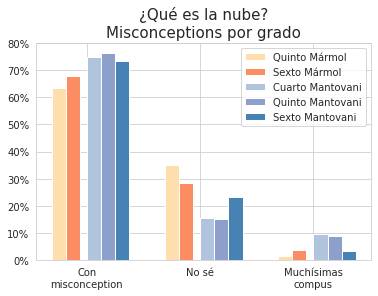

In [5]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿Qué es la nube? - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()

result = pd.concat([ df_con_mis,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception",
                                1: "No sé",
                                2: "Muchísimas\ncompus"}).transpose()

print(result*100)

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nMisconceptions por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_no-se_no-misco_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

In [ ]:
# En informática, ¿qué es la nube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Una nube": "Una\nnube",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

result = result.reindex(["Una red de\nantenas y\nsatélites",
                         "No sé",
                         "Una\nparte del\ncelular",
                         "Una\nnube",
                         "Muchísimas\ncompus",
                         "Una\ncompu\ngigante"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nPor género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Las respuestas analizadas en base al género del Modelo Mármol y Juan Mantovani son iguales:
* Las chicas eligen un 10% menos "Una red...", las chicas eligen un 10% más "No se" y un 5% más "Una parte del celular".
* Los varones del Mantovani eligen un 5% más "Muchisimas compus"

In [ ]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿qué es la nube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\ncompus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nMisconceptions por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(fig_name_prefix + '_misco_agregadas_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En ambos colegios se reducen las misconcaptions en el sexo femenino

In [ ]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿qué es la nube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index!='Una red de\nantenas y\nsatélites') &
                               (result.index!='No sé') &
                               (result.index!='Muchísimas\ncompus')].sum()

result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Una red de\nantenas y\nsatélites'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "Una red de\nantenas y\nsatélites",
                                2: "No sé",
                                3: "Muchísimas\ncompus"}).transpose()

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nMisconceptions fuertes por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Las chicas responden levemente mas con miscon fuerte en el mantovani
* Las chicas responden 10% menos "misconc debil" que los varones
* Las chicas responden más no se en ambos colegios.
* Las chicas responden menos la opcion sin msiconception en ambos colegios

                    Masculino Mármol  Femenino Mármol  Masculino Mantovani  \
Con\nmisconception         70.666667        60.869565            77.310924   
No sé                      25.333333        37.681159            11.764706   
Muchísimas\ncompus          4.000000         1.449275            10.924370   

                    Femenino Mantovani  
Con\nmisconception           71.428571  
No sé                        24.489796  
Muchísimas\ncompus            4.081633  


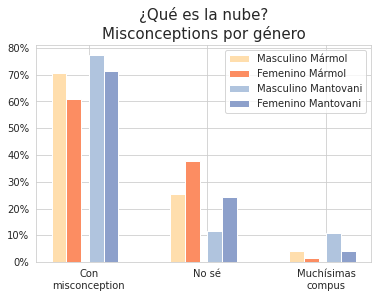

In [6]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿qué es la nube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\nantenas y\nsatélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\nparte del\ncelular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "Una computadora gigante":"Una\ncompu\ngigante"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()

result = pd.concat([ df_con_mis,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception",
                                1: "No sé",
                                2: "Muchísimas\ncompus"}).transpose()

print(result*100)

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("¿Qué es la nube?\nMisconceptions por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_no-se_no-misco_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)